# 02 — Funnel Metrics & Visualization

Calculate the core email-marketing metrics at overall and campaign-type level, then visualize the funnel and campaign comparison.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import plotly.graph_objects as go
sns.set_theme(style='whitegrid')
PAL = ['#2E5EAA','#5BC0BE','#F4A259','#E76F51']
df = pd.read_csv('../data/cleaned_email_data.csv', parse_dates=['sent_date','sent_week'])
df.shape

(10000, 14)

## Step 2 — Metric definitions
| Metric | Formula |
|---|---|
| Delivery Rate | Delivered / Sent |
| Open Rate | Opened / Delivered |
| CTR | Clicked / Delivered |
| CTOR | Clicked / Opened |
| Conversion Rate | Converted / Clicked |
| Unsubscribe Rate | Unsubscribed / Delivered |
| Bounce Rate | Bounced / Sent |

In [2]:
def funnel_metrics(d):
    sent=len(d); deliv=d.delivered.sum(); op=d.opened.sum()
    cl=d.clicked.sum(); cv=d.converted.sum(); un=d.unsubscribed.sum()
    return pd.Series({'Sent':sent,'Delivered':deliv,'Opened':op,'Clicked':cl,'Converted':cv,
        'Delivery Rate':deliv/sent,'Open Rate':op/deliv,'CTR':cl/deliv,'CTOR':cl/op,
        'Conversion Rate':cv/cl,'Unsubscribe Rate':un/deliv,'Bounce Rate':(sent-deliv)/sent})

overall = funnel_metrics(df)
overall[['Delivery Rate','Open Rate','CTR','CTOR','Conversion Rate','Unsubscribe Rate','Bounce Rate']].apply(lambda x:f'{x:.2%}')

Delivery Rate       94.98%
Open Rate           32.03%
CTR                 10.41%
CTOR                32.51%
Conversion Rate     29.93%
Unsubscribe Rate     1.64%
Bounce Rate          5.02%
dtype: str

### Metrics by campaign type

In [3]:
by_campaign = df.groupby('campaign_type').apply(funnel_metrics, include_groups=False).reset_index()
by_campaign[['campaign_type','Open Rate','CTR','Conversion Rate','Unsubscribe Rate']].style.format({
    'Open Rate':'{:.2%}','CTR':'{:.2%}','Conversion Rate':'{:.2%}','Unsubscribe Rate':'{:.2%}'})

,campaign_type,Open Rate,CTR,Conversion Rate,Unsubscribe Rate
0,Newsletter,31.06%,8.37%,30.57%,1.53%
1,Promotional,30.33%,10.17%,27.77%,1.68%
2,Welcome,36.20%,13.18%,32.49%,1.70%


## Step 3 — Interactive funnel chart (Plotly)

In [4]:
stages=['Sent','Delivered','Opened','Clicked','Converted']
values=[int(overall[s]) for s in stages]
fig=go.Figure(go.Funnel(y=stages,x=values,textinfo='value+percent initial',
    marker={'color':['#2E5EAA','#3A7CA5','#5BC0BE','#F4A259','#E76F51']}))
fig.update_layout(title='Email Marketing Funnel', width=850, height=500)
fig.write_image('../visuals/funnel_chart.png', scale=2)
fig.show()

In [5]:
print('Stage-to-stage drop-off:')
for i in range(1,len(values)):
    print(f'  {stages[i-1]} -> {stages[i]}: {(values[i]-values[i-1])/values[i-1]:+.1%}')

Stage-to-stage drop-off:
  Sent -> Delivered: -5.0%
  Delivered -> Opened: -68.0%
  Opened -> Clicked: -67.5%
  Clicked -> Converted: -70.1%


## Step 4 — Campaign comparison (grouped bar)

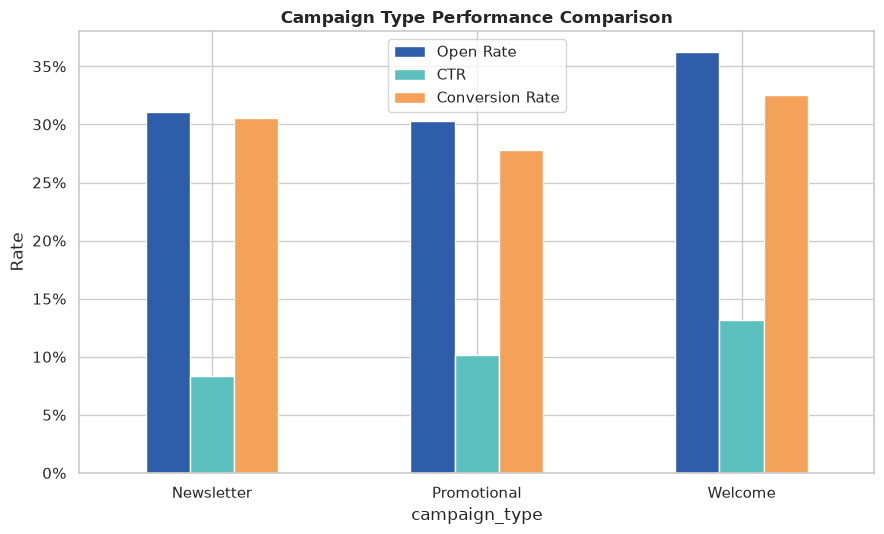

Best converting campaign: Welcome


In [6]:
mp = by_campaign.set_index('campaign_type')[['Open Rate','CTR','Conversion Rate']]
ax = mp.plot(kind='bar', figsize=(9,5.5), color=PAL[:3], edgecolor='white')
ax.set_title('Campaign Type Performance Comparison', weight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.0%}'))
ax.set_xticklabels(mp.index, rotation=0); ax.set_ylabel('Rate')
plt.tight_layout(); plt.savefig('../visuals/campaign_comparison.png', dpi=120, bbox_inches='tight'); plt.show()
print('Best converting campaign:', by_campaign.loc[by_campaign["Conversion Rate"].idxmax(),'campaign_type'])

**Takeaway:** The biggest drop-off is between *Delivered → Opened* and *Opened → Clicked*. **Welcome** emails outperform on every metric — the clearest lever for improving funnel efficiency.